In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = pd.read_csv(r"C:\Users\Shikhar Khanna\Downloads\Programming\Car Price prediction model\car_ad.csv", encoding='latin1')

In [3]:
data.head()

,car,price,body,mileage,engV,engType,registration,year,model,drive
0,Ford,15500.0,crossover,68,2.5,Gas,yes,2010,Kuga,full
1,Mercedes-Benz,20500.0,sedan,173,1.8,Gas,yes,2011,E-Class,rear
2,Mercedes-Benz,35000.0,other,135,5.5,Petrol,yes,2008,CL 550,rear
3,Mercedes-Benz,17800.0,van,162,1.8,Diesel,yes,2012,B 180,front
4,Mercedes-Benz,33000.0,vagon,91,NaN,Other,yes,2013,E-Class,NaN


In [4]:
data.shape

(9576, 10)

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9576 entries, 0 to 9575
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   car           9576 non-null   object 
 1   price         9576 non-null   float64
 2   body          9576 non-null   object 
 3   mileage       9576 non-null   int64  
 4   engV          9142 non-null   float64
 5   engType       9576 non-null   object 
 6   registration  9576 non-null   object 
 7   year          9576 non-null   int64  
 8   model         9576 non-null   object 
 9   drive         9065 non-null   object 
dtypes: float64(2), int64(2), object(6)
memory usage: 748.3+ KB


In [6]:
data.describe()

,price,mileage,engV,year
count,9576.000000,9576.000000,9142.000000,9576.000000
mean,15633.317316,138.862364,2.646344,2006.605994
std,24106.523436,98.629754,5.927699,7.067924
min,0.000000,0.000000,0.100000,1953.000000
25%,4999.000000,70.000000,1.600000,2004.000000
50%,9200.000000,128.000000,2.000000,2008.000000
75%,16700.000000,194.000000,2.500000,2012.000000
max,547800.000000,999.000000,99.990000,2016.000000


In [7]:
data.isnull().sum()

car               0
price             0
body              0
mileage           0
engV            434
engType           0
registration      0
year              0
model             0
drive           511
dtype: int64

In [8]:
data.isnull().sum().sum()

np.int64(945)

In [9]:
data["drive"].unique()

array(['full', 'rear', 'front', nan], dtype=object)

In [10]:
data["drive"].value_counts()

drive
front    5188
full     2500
rear     1377
Name: count, dtype: int64

In [11]:
data['drive'].fillna(data['drive'].mode()[0], inplace=True)

C:\Users\Shikhar Khanna\AppData\Local\Temp\ipykernel_6188\2195522589.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['drive'].fillna(data['drive'].mode()[0], inplace=True)


In [73]:
data.isnull().sum()

car                0
price              0
body               0
mileage            0
engV               0
engType            0
registration       0
year               0
model              0
drive              0
car_age            0
engine_per_year    0
mileage_log        0
engine_category    0
is_expensive       0
is_premium         0
dtype: int64

In [74]:
data = data.dropna(subset=['price'])
data.reset_index(drop=True, inplace=True)

In [75]:
data['car_age'] = 2024 - data['year']
data = data[data['car_age'] > 0]

In [76]:
data['engV'] = data.groupby('car')['engV'].transform(lambda x: x.fillna(x.median()))

In [77]:
data = data[data['price'] < data['price'].quantile(0.99)]
data = data[data['mileage'] < data['mileage'].quantile(0.99)]

In [78]:
data['car'] = data['car'].apply(lambda x: x if x in top_brands else 'Other')

In [79]:
data['mileage_log'] = np.log1p(data['mileage'])

In [80]:
data['engine_category'] = pd.cut(
    data['engV'],
    bins=[0, 1.5, 2.5, 4, 10],
    labels=['small', 'medium', 'large', 'very_large']
)

In [81]:
premium_brands = ['BMW', 'Mercedes-Benz', 'Audi', 'Lexus']
data['is_premium'] = data['car'].apply(lambda x: 1 if x in premium_brands else 0)

In [82]:
data.replace([np.inf, -np.inf], np.nan, inplace=True)
data.dropna(inplace=True)

In [83]:
X = data.drop('price', axis=1)
y = np.log1p(data['price'])

In [84]:
X = pd.get_dummies(X, drop_first=True)

In [85]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [86]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=300,
    max_depth=15,
    min_samples_split=5,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

,n_estimators,300
,criterion,'squared_error'
,max_depth,15
,min_samples_split,5
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [87]:
y_pred = model.predict(X_test)

In [88]:
y_pred_actual = np.expm1(y_pred)
y_test_actual = np.expm1(y_test)

In [89]:
from sklearn.metrics import r2_score, mean_absolute_error

r2 = r2_score(y_test_actual, y_pred_actual)
mae = mean_absolute_error(y_test_actual, y_pred_actual)

print("R2 Score:", r2)
print("MAE:", mae)

R2 Score: 0.8684164793075664
MAE: 2228.938384256316


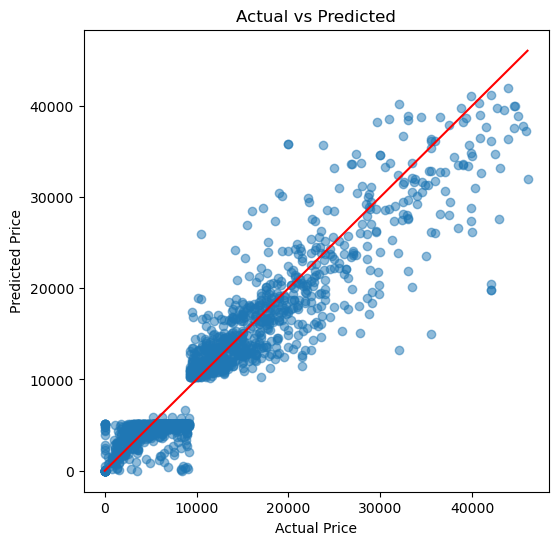

In [90]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.scatter(y_test_actual, y_pred_actual, alpha=0.5)

plt.plot([y_test_actual.min(), y_test_actual.max()],
         [y_test_actual.min(), y_test_actual.max()],
         color='red')

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted")

plt.show()

In [91]:
importance = pd.Series(model.feature_importances_, index=X.columns)
print(importance.sort_values(ascending=False).head(10))

engine_per_year       0.431411
is_expensive          0.311335
engV                  0.023918
car_age               0.020476
year                  0.015192
mileage               0.008588
mileage_log           0.008204
car_Other             0.005452
registration_yes      0.005319
model_Pajero Sport    0.004663
dtype: float64


In [92]:
print("Train R2:", model.score(X_train, y_train))
print("Test R2:", model.score(X_test, y_test))

Train R2: 0.8028920211954805
Test R2: 0.6564808116286448


In [94]:
def predict_car_price():
    print("Enter Car Details:")

    car = input("Car Brand (e.g., BMW, Audi): ")
    mileage = float(input("Mileage: "))
    engV = float(input("Engine Volume (e.g., 2.0): "))
    year = int(input("Year: "))
    drive = input("Drive type (front/rear/4x4): ")
    body = input("Body type (sedan, hatchback, etc): ")
    engType = input("Engine type (petrol/diesel): ")
    registration = input("Registration (yes/no): ")

    # Create dataframe
    new_data = pd.DataFrame({
        'car': [car],
        'mileage': [mileage],
        'engV': [engV],
        'year': [year],
        'drive': [drive],
        'body': [body],
        'engType': [engType],
        'registration': [registration]
    })

    # Apply same feature engineering
    new_data['car_age'] = 2024 - new_data['year']
    new_data['mileage_log'] = np.log1p(new_data['mileage'])

    # Brand grouping
    top_brands = data['car'].value_counts().head(10).index
    new_data['car'] = new_data['car'].apply(lambda x: x if x in top_brands else 'Other')

    # Encoding
    new_data = pd.get_dummies(new_data)

    # Match training columns
    new_data = new_data.reindex(columns=X.columns, fill_value=0)

    # Predict
    pred_log = model.predict(new_data)
    pred_price = np.expm1(pred_log)

    print("\n💰 Predicted Car Price:", round(pred_price[0], 2))

In [96]:
predict_car_price()

Enter Car Details:


Car Brand (e.g., BMW, Audi):  BMW
Mileage:  8
Engine Volume (e.g., 2.0):  2.8
Year:  2021
Drive type (front/rear/4x4):  4*4
Body type (sedan, hatchback, etc):  sedan
Engine type (petrol/diesel):  petrol
Registration (yes/no):  yes



💰 Predicted Car Price: 3194.68
